<p style="font-family:'Lucida Calligraphy', cursive;font-size:40px;color:purple; text-align:center;">
    <b> <u>Project Title:Unlocking Customer Insights: A Statistical Investigation</u></b></p1>

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Business Problem Statement</u>:</p>
<span style="font-family: 'Georgia'; font-size: 18px;">A mid-sized Indian retail company is sitting on a treasure trove of customer data — but
lacks clarity on what story it tells. They need a team of analysts to conduct a rigorous
statistical investigation to validate business assumptions, uncover hidden patterns, and
support data-driven decision-making.</br>
As a data analytics intern, we have been tasked with:</br>
● Using statistical tools to explore and summarize the dataset</br>
● Comparing customer behavior across demographic segments</br>
● Testing business hypotheses using statistical methods</br>
</style></p>

<p style="font-family: 'Georgia'; font-size: 30px;"> Data Description:</br></p></br>

<b><i>CustomerID</b> - Unique identifier for each customer</br>
    
<b>Name</b> - Customer's full name</br>
    
<b>State</b> - US state where the customer resides</br>

<b>Education</b> - Highest level of education attained (High School to PhD)</br>
    
<b>Gender</b> - Gender identity (Male, Female, Non-Binary)</br>

<b>Age</b> -Age of the customer (between 18 and 80)</br>

<b>Married </b> - Marital status: Yes or No</br>

<b>NumPets</b> - Number of pets owned by the customer (0 to 4)</br>

<b>MonthlySpend</b> - Amount spent monthly in USD, generated using a skewed Gamma distribution</br>

<b>DaysSinceLastInteraction</b> - Number of days since last interaction with the company</br></i>



<p style="font-family: 'Georgia'; font-size: 30px;"><u>Import Libraries</u></p>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import kstest
from scipy.stats import anderson

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Data Prepration</u></p>

In [6]:
# Load the file
insights=pd.read_csv("US_Customer_Insights_Dataset.csv")

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Understand the Data Information</u></p>

In [7]:
# Preview the data
print("Customers Insights Data:")
print(insights.head())


Customers Insights Data:
  CustomerID              Name       State    Education      Gender  Age  \
0  CUST10319       Scott Perez     Florida  High School  Non-Binary   47   
1  CUST10695   Jennifer Burton  Washington       Master        Male   72   
2  CUST10297   Michelle Rogers     Arizona       Master      Female   40   
3  CUST10103  Brooke Hendricks       Texas       Master        Male   27   
4  CUST10219       Karen Johns       Texas  High School      Female   28   

  Married  NumPets JoinDate TransactionDate  MonthlySpend  \
0     Yes        1  9/19/21          9/2/24       1281.74   
1     Yes        0   4/5/24          6/2/24        429.46   
2     Yes        2  7/24/24         2/28/25        510.34   
3     Yes        0  8/12/23         3/29/25        396.47   
4     Yes        1  12/6/21         7/24/22        139.68   

   DaysSinceLastInteraction  
0                       332  
1                       424  
2                       153  
3                       124  
4

In [8]:
# # Understanding the different columns present in the dataset and its datatype
insights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [9]:
# Understanding the statistical summary of the numerical data
insights.describe()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000,10675.000000
mean,49.474567,1.340515,331.610315,538.469883
std,18.221365,1.150849,225.799253,398.766747
min,18.000000,0.000000,3.890000,1.000000
25%,35.000000,0.000000,165.495000,218.000000
50%,49.000000,1.000000,282.110000,445.000000
75%,66.000000,2.000000,443.255000,788.500000
max,80.000000,4.000000,1740.420000,1791.000000


In [10]:
# Total number of rows and columns
insights.shape

(10675, 12)

In [11]:
# List of numerical column names
insights.select_dtypes(include='number').columns

Index(['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction'], dtype='object')

In [12]:
# List of categorical column names
insights.select_dtypes(exclude='number').columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Married',
       'JoinDate', 'TransactionDate'],
      dtype='object')

In [13]:
# Data types of each column
insights.dtypes

CustomerID                   object
Name                         object
State                        object
Education                    object
Gender                       object
Age                           int64
Married                      object
NumPets                       int64
JoinDate                     object
TransactionDate              object
MonthlySpend                float64
DaysSinceLastInteraction      int64
dtype: object

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Cleaning The Data</u></p>

In [14]:
# Checking Null Values/missing values: 
print("Check for missing values in each column:")
insights.isnull().sum()


Check for missing values in each column:


CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

#### *Conclusion: There are no missing values, so we can proceed with confidence.* ####

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Checking Duplicate Records</u></p>

In [15]:
# Finding if data has duplicate records
insights.duplicated().sum()

np.int64(0)

#### ***Conclusion: Their is no duplicate records in the data.***

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Checking Unique Values</u></p>

In [16]:
# Unique():
insights["CustomerID"].unique()
       
insights["Name"].unique()
insights["State"].unique()
insights["Education"].unique()
insights["Gender"].unique()
insights["Married"].unique()
insights["JoinDate"].unique()
insights["TransactionDate"].unique()

array(['9/2/24', '6/2/24', '2/28/25', ..., '1/11/22', '4/7/22', '6/4/21'],
      shape=(1605,), dtype=object)

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Descriptive Statistics</u></p>
 Describe your customer base — how old are they, how much do they
spend, are they active?</br>
● Compute:
o Mean, median, std dev for Age, MonthlySpend, DaysSinceLastInteraction
o Mode for categorical variables: Gender, Education, Married

##### **Calculate  Mean , Median , Standard Deviation:**

In [17]:
# o Mean, median, std dev for Age, MonthlySpend, DaysSinceLastInteraction 
insights[['Age','MonthlySpend','DaysSinceLastInteraction']].agg(['mean','median','std'])

,Age,MonthlySpend,DaysSinceLastInteraction
mean,49.474567,331.610315,538.469883
median,49.000000,282.110000,445.000000
std,18.221365,225.799253,398.766747


In [18]:
#  o Mode for categorical variables: Gender, Education, Married
insights[['Gender','Education','Married']].mode()

,Gender,Education,Married
0,Male,Master,No


<p style="font-family: 'Georgia'; font-size: 30px;"><u>Data Visualization</u></p>
Reveal patterns that numbers alone can’t show.</br>
● Plot histograms and boxplots for Age, MonthlySpend</br>
● Create a bar chart for Gender, Education, State</br>
● Scatterplot: Age vs MonthlySpend</br>
● KDE: Spending behavior by education level or marital status.</br>

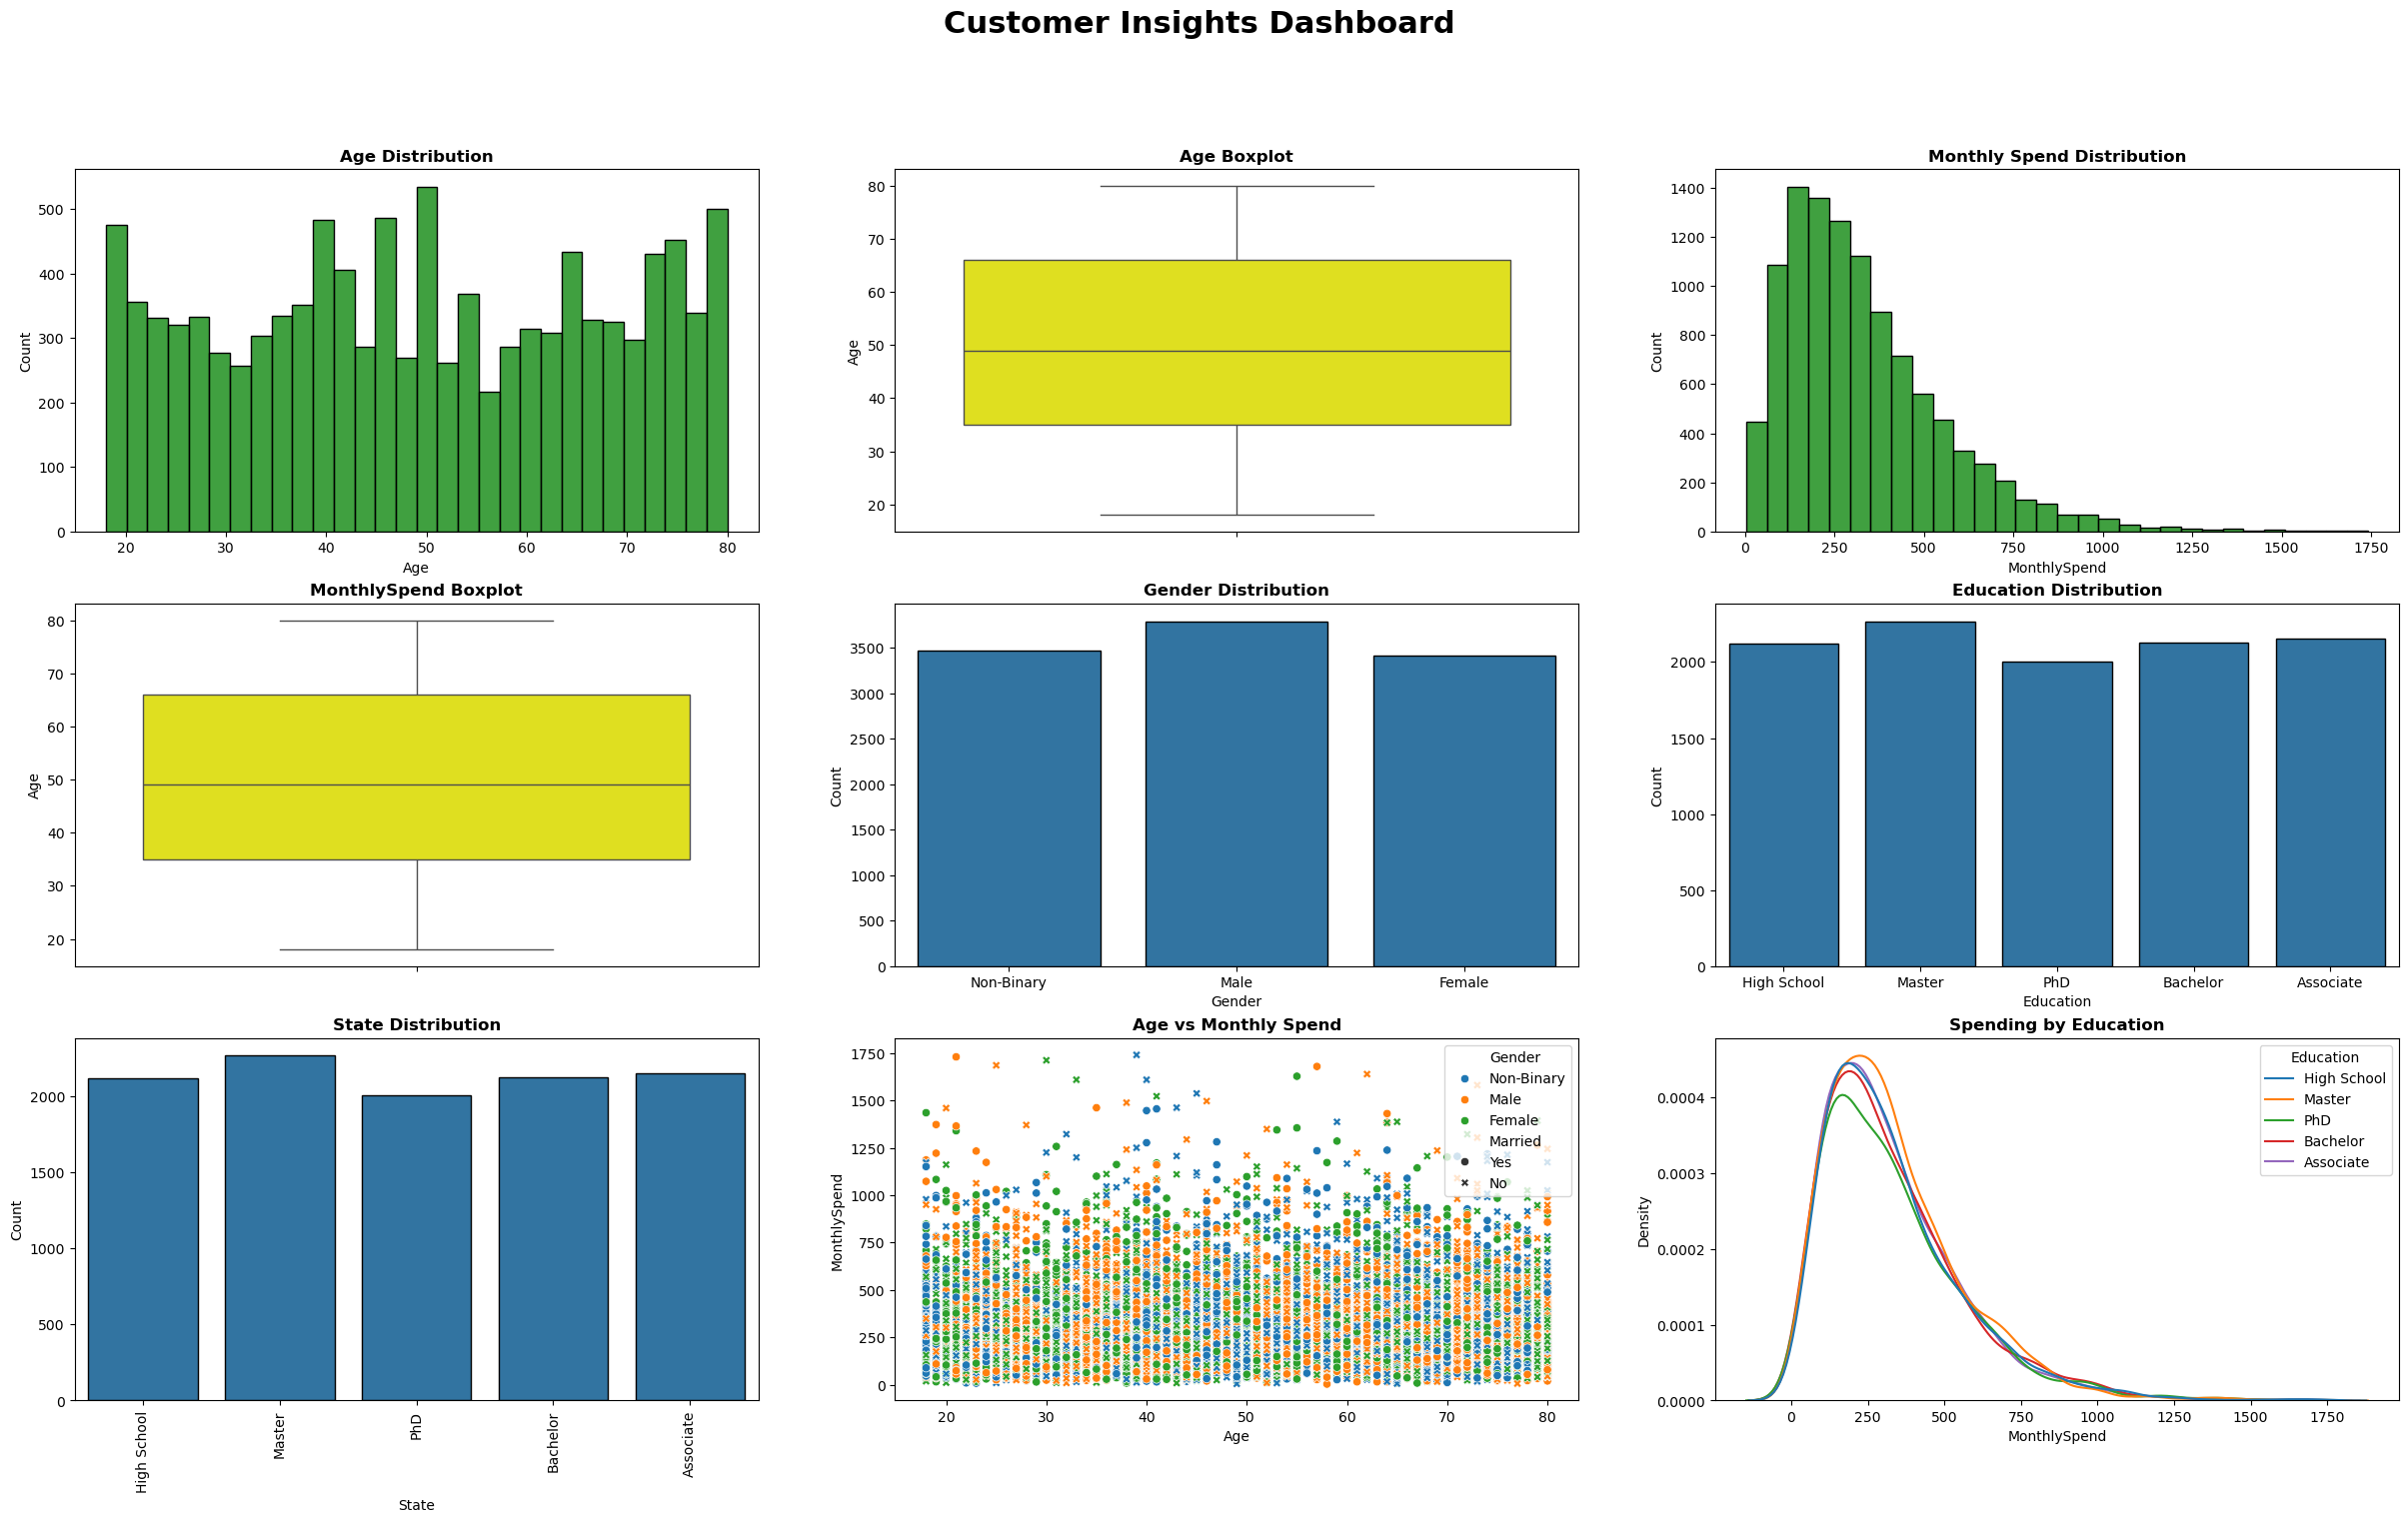

In [19]:
# ● Create a dashboard style figure with multiple subplots
plt.figure(figsize=(30,16))

# 1.Plot histograms  for Age, MonthlySpend
plt.subplot(3,3,1)
sns.histplot(x="Age", data=insights, bins=30,color="green")
plt.title("Age Distribution",fontsize=12,fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Count")

# 2. Boxplot for Age
plt.subplot(3,3,2)
sns.boxplot(y="Age", data=insights,color="yellow")
plt.title("Age Boxplot", fontsize=12, fontweight='bold')
plt.ylabel("Age")


# 3. Histogram for MonthlySpend
plt.subplot(3,3,3)
sns.histplot(x="MonthlySpend", data=insights, bins=30,color="green")
plt.title("Monthly Spend Distribution",fontsize=12, fontweight='bold')
plt.xlabel("MonthlySpend")
plt.ylabel("Count")

# 4. Boxplots for MonthlySpend
plt.subplot(3,3,4)
sns.boxplot(y="Age", data=insights,color="yellow")
plt.title("MonthlySpend Boxplot",fontsize=12, fontweight='bold')


# ● Create a bar chart for Gender, Education, State
# 5.Bar chart for  Gender
plt.subplot(3,3,5)
sns.countplot(x='Gender', data=insights, edgecolor='black')
plt.title("Gender Distribution",fontsize=12, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")

# 6. Bar chart for Education
plt.subplot(3,3,6)
sns.countplot(x='Education', data=insights, edgecolor='black')
plt.title("Education Distribution",fontsize=12, fontweight='bold')
plt.xlabel("Education")
plt.ylabel("Count")

# 7. Bar chart for State
plt.subplot(3,3,7)
sns.countplot(x='Education', data=insights, edgecolor='black')
plt.title("State Distribution",fontsize=12, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=90)


# 8. Scatterplot: Age vs MonthlySpend
plt.subplot(3,3,8)
sns.scatterplot(y='MonthlySpend',x='Age',data=insights,hue="Gender",style="Married")
plt.title("Age vs Monthly Spend",fontsize=12, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("MonthlySpend")


# 9. KDE: Spending behavior by education level or marital status
plt.subplot(3, 3, 9)
sns.kdeplot(data=insights,x='MonthlySpend',hue='Education',fill=False)
plt.title('Spending by Education', fontsize=12, fontweight='bold')
plt.xlabel('MonthlySpend')
plt.ylabel('Density')

plt.suptitle("Customer Insights Dashboard", fontsize=22, fontweight="bold")

plt.show()

<p style="font-family: 'Georgia'; font-size: 30px;"><u>Bivariate Analysis</u></p>
Check how customer attributes relate to one another.</br>
● Correlation matrix (numeric variables)</br>
● Crosstab of Gender vs Married</br>
● Grouped stats: average MonthlySpend by State, Education, GenderStep</br>

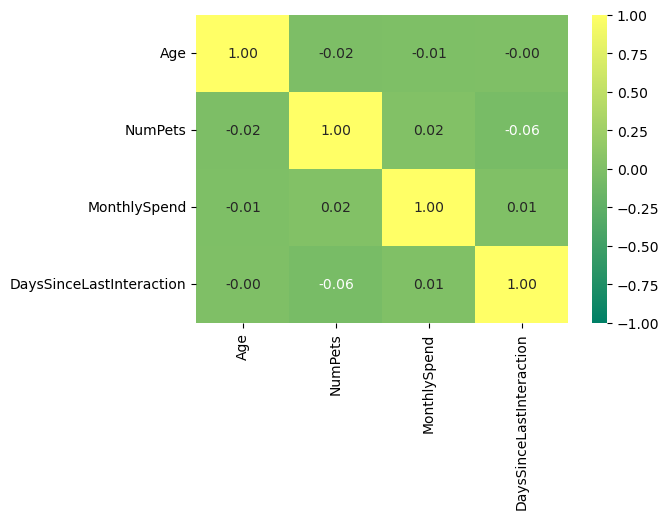

In [20]:
# ● Correlation matrix (numeric variables)
plt.figure(figsize=(6,4))
sns.heatmap(insights.corr(numeric_only=True), annot=True,cmap="summer",fmt=".2f",vmin=-1,vmax=1)
plt.show()

In [21]:
# ● Crosstab of Gender vs Married
pd.crosstab(insights["Gender"], insights["Married"])

Married,No,Yes
Gender,,
Female,1797,1616
Male,1892,1899
Non-Binary,1894,1577


In [22]:
# ● Grouped stats: average MonthlySpend by State, Education, Gender
grouped_stats = insights.groupby(
    ["State", "Education", "Gender"]
)["MonthlySpend"].mean().reset_index()

print("Average Monthly Spend by State, Education, and Gender:\n")
print(grouped_stats)

Average Monthly Spend by State, Education, and Gender:

          State  Education      Gender  MonthlySpend
0       Arizona  Associate      Female    329.187368
1       Arizona  Associate        Male    360.346500
2       Arizona  Associate  Non-Binary    316.102045
3       Arizona   Bachelor      Female    330.911944
4       Arizona   Bachelor        Male    344.251266
..          ...        ...         ...           ...
145  Washington     Master        Male    305.584615
146  Washington     Master  Non-Binary    318.771333
147  Washington        PhD      Female    368.058765
148  Washington        PhD        Male    333.002703
149  Washington        PhD  Non-Binary    351.268642

[150 rows x 4 columns]


<p style="font-family: 'Georgia'; font-size: 30px;"><u>Formulate Hypotheses & Run Hypothesis Tests</u></p></b></p>

Business Purpose: Turn business questions into statistical tests.</br>

**Business Question**                                                         | **Statistical Test** 
----------------------------------------------------------------------------- | -------------------- 
 Do males and females spend differently?                                      | Independent t-test   
 Does education level impact average monthly spend?                           | One-way ANOVA        
 Is marital status related to the number of pets owned? (Only for DS Students)| Chi-square test      
 Are older people less active? (Age vs DaysSinceLastInteraction)              | Correlation          
 Does state-wise spend vary significantly?                                    | ANOVA                
**Step 6: Run Hypothesis Tests**
Business Purpose: Validate or reject your assumptions with confidence.
● Define null and alternate hypotheses
● Choose test based on data types
● Check assumptions: normality, independence, homogeneity of variance
● Interpret p-values and confidence intervals

In [23]:
# Test 1 : Independent t-test  -Do males and females spend differently?

male_spend = insights[insights["Gender"] == "Male"]["MonthlySpend"]
female_spend = insights[insights["Gender"] == "Female"]["MonthlySpend"]

# Perform t-test
t_stat, p_value = ttest_ind(male_spend, female_spend, equal_var=False)

print(f'T-statistic:{t_stat:.4f}')
print(f'P-value:{p_value:.4f}')

alpha=0.05
if p_value < alpha:
    print("Conclusion: Reject null hypothesis → There is a significant difference in spending by gender.")
else:
    print("Conclusion: Fail to Reject null hypothesis → There is no significant difference in spending by gender.")

T-statistic:0.3391
P-value:0.7345
Conclusion: Fail to Reject null hypothesis → There is no significant difference in spending by gender.


In [24]:
# Test 2 : One-way ANOVA - Does education level impact average monthly spend?
groups = [group["MonthlySpend"].values 
          for name, group in insights.groupby("Education")]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha=0.05
if p_value < alpha:
    print("Conclusion: Reject null hupothesis →There is a statistically significant difference in average monthly spending across different education levels.")
else:
    print("Conclusion: Fail to reject null hypothesis → There is no statistically significant difference in average monthly spending across different education levels.")

F-statistic: 0.2288
P-value: 0.9224
Conclusion: Fail to reject null hypothesis → There is no statistically significant difference in average monthly spending across different education levels.


In [25]:
# Test 3: Chi-square test - Is marital status related to the number of pets owned? (Only for DS Students)
alpha = 0.05

# Create contingency table
contingency_table = pd.crosstab(insights['Married'], insights['NumPets'])

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Conclusion: Reject null hypothesis. There IS a significant association between marital status and number of pets owned.")
else:
    print("Conclusion: Fail to reject null hypothesis. No significant association between marital status and number of pets owned.")

Chi-square statistic: 177.6395
Degrees of freedom: 4
P-value: 0.0000
Conclusion: Reject null hypothesis. There IS a significant association between marital status and number of pets owned.


In [26]:
# Test 4: Correlation - Are older people less active? (Age vs DaysSinceLastInteraction)

alpha = 0.05

# Perform Pearson correlation test
corr, p_value = pearsonr(insights['Age'], insights['DaysSinceLastInteraction'])

print(f"Correlation coefficient: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Conclusion: Reject null hypothesis. There IS a significant relationship between Age and DaysSinceLastInteraction.")
    
    if corr > 0:
        print("As age increases, days since last interaction increases (older people are less active).")
    else:
        print("As age increases, days since last interaction decreases (older people are more active).")
        
else:
    print("Conclusion: Fail to reject null hypothesis. No significant relationship between Age and DaysSinceLastInteraction.")

Correlation coefficient: -0.0040
P-value: 0.6817
Conclusion: Fail to reject null hypothesis. No significant relationship between Age and DaysSinceLastInteraction.


In [27]:
# Test 5: ANOVA - Does state-wise spend vary significantly?

alpha = 0.05

# Create groups based on State
groups = [group["MonthlySpend"].values 
          for name, group in insights.groupby("State")]

# Perform One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Conclusion: Reject null hypothesis. There IS a significant difference in Monthly Spend across states.")
else:
    print("Conclusion: Fail to reject null hypothesis. No significant difference in Monthly Spend across states.")

F-statistic: 1.1178
P-value: 0.3457
Conclusion: Fail to reject null hypothesis. No significant difference in Monthly Spend across states.


Step 6 some questions:

In [28]:
# Normality Check for t-test & Anova

# Standardize data first
data = (insights["MonthlySpend"] - insights["MonthlySpend"].mean()) / insights["MonthlySpend"].std()

stat, p_value = kstest(data, 'norm')

print("KS Test p-value:", p_value)

if p_value > 0.05:
    print("Data is normally distributed")
else:
    print("Data is not normally distributed")           

KS Test p-value: 1.7334902885382592e-82
Data is not normally distributed


In [29]:
# Homogeneity of Variance

from scipy.stats import levene

stat, p = levene(male_spend, female_spend)
print("Levene p-value:", p)

if p > 0.05:
    print("Equal variances assumed")
else:
    print("Variances are not equal")

Levene p-value: 0.7218295518516542
Equal variances assumed


In [30]:
# Independence: Observations are independent as each customer represents a unique entry.(No Code is required)

In [31]:
# ● Interpret p-values and confidence intervals
# p-values is shown above
# Confidence Intervals:
diff = male_spend.mean() - female_spend.mean()

se = np.sqrt(male_spend.var()/len(male_spend) +
             female_spend.var()/len(female_spend))

ci = stats.t.interval(0.95,
                      df=len(male_spend)+len(female_spend)-2,
                      loc=diff,
                      scale=se)

print("95% Confidence Interval:",ci)

95% Confidence Interval: (np.float64(-8.665623261458899), np.float64(12.291138921746887))


## Step 7: Present Business Insights ##
Business Purpose: Translate stats into strategy.</br>
Create 4–5 takeaways. For example:</br>
● “Customers with Master’s degrees spend 18% more per month on average.”</br>
● “Non-married customers with pets show the highest re-engagement potential.”</br>
● “Florida and Texas show the greatest variability in spending — personalize your
campaigns by state.”</br>

#### 1️. Gender-Based Spending Insight

If significant:

Male and female customers show a significant difference in monthly spending. This suggests that gender-specific marketing strategies may improve targeting effectiveness.

If not significant:

Spending behavior is similar across genders, so gender-based segmentation may not be necessary.

#### 2️. Education Impact Insight

If significant:

Education level significantly influences monthly spending. Higher-educated customers tend to spend more, indicating potential for premium product targeting.

If not significant:

Spending patterns are consistent across education levels, suggesting education is not a strong driver of purchasing behavior.

#### 3️. Marital Status & Pet Ownership Insight

If significant:

Marital status is associated with pet ownership. Married customers may represent a stronger market for pet-related products.

If not significant:

Pet ownership appears independent of marital status, so marketing should not rely on marital segmentation.

#### 4️. Age & Customer Activity Insight

If positive correlation (older less active):

Older customers tend to interact less frequently. Engagement campaigns should focus on retaining older age segments.

If no correlation:

Customer activity levels are not strongly influenced by age.

#### 5️. State-Wise Spending Insight

If significant:

Spending varies significantly across states. Regional marketing strategies and pricing customization may increase revenue.

If not significant:

Customer spending patterns are consistent across states, allowing uniform marketing strategies nationwide.